In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('/zhome/71/c/146676/main/')
import SimpleITK as sitk
import importlib
from helpers import module_auxiliary as ma
from matplotlib_scalebar.scalebar import ScaleBar
from cil.optimisation.operators import GradientOperator # For extract edge function
import matplotlib
#matplotlib.use('Agg')
from segmentation import s3_watershed_eds
importlib.reload(s3_watershed_eds)
import matplotlib.colors as mcolors
import copy
from segmentation import s2_watershed_filter

In [2]:
full_seg_, segmentation_, elem_segm_, elems_ = s3_watershed_eds.get_segmentation_from_watersheds(
    thresholds = np.array([15, 15, 15, 10 , 20, 20, 30, 12, 5 , 30, 10, 13 , 92, 15, 5]),
    output=True)
segmentation = {}
for key in segmentation_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(segmentation_[key].astype(np.float32))
        segmentation[key] = s3_watershed_eds.transform_eds(segmentation_[key].astype(np.float32))

elem_segm = {}
for key in elem_segm_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(elem_segm_[key].astype(np.float32))
        elem_segm[key] = s3_watershed_eds.transform_eds(elem_segm_[key].astype(np.float32))

elems = {}
for key in elems_:
    if key != "labels":
        
        moving = sitk.GetImageFromArray(elems_[key].astype(np.float32))
        elems[key] = s3_watershed_eds.transform_eds(elems_[key].astype(np.float32))

moving = sitk.GetImageFromArray(full_seg_)
full_seg = s3_watershed_eds.transform_eds(full_seg_)

In [3]:
def plot_segmentations(background, ground_truth_seg, test_seg = None, class_labels = None,transparencies = [0.7, 0.5]):
    #plt.close('all)')
    Ns = np.max(ground_truth_seg)
    if class_labels is not None:
        Ns = 12
    if class_labels is None:
        class_labels = "".join(map(str, range(0, Ns)))
    # Add black as the first color

    colors_d = [
        (0, 0, 255),      # Blue Plagio
        (128, 0, 128),    # Purple Alk
        (255, 50, 150),   # Pink   #cpx
        (0, 255, 0),      # Green   # opx
        (255, 165, 0),    # Orange     #apatite
        (160, 255, 0),    # Brown Ilminite
        (0, 170, 255),    # light blue, chromite
        (255, 0, 0),    #  pyrite   
        (255, 0, 255),   # Magenta, Baddelyite
        (0, 255, 255) # Cyan
    ]

    color_strings = ['blue',  'purple', 'pink', 'lime', 'orange', 'cyan', 'yellow', 'red',
               'magenta','brown','black', 'white']

    # Convert RGB to normalized values and prepend a transparent color
    colors_d = [mcolors.to_rgb(color) for color in color_strings]
    colors_d = [(0, 0, 0, 0.7)] + [(r, g, b, 0.5) for r, g, b in colors_d[:Ns]]

    # Create the colormap
    cmap_d = mcolors.ListedColormap(colors_d)
    boundaries = np.arange(-0.5, Ns+1, 1)  # [-0.5, 0.5, 1.5, ..., 14.5]
    norm = mcolors.BoundaryNorm(boundaries, cmap_d.N)
    # Plot the matrix with the custom colormap
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(background, cmap="gray", vmin = 0.01, vmax = 50)  # Adjust alpha for blending

    im = ax.imshow(ground_truth_seg, cmap=cmap_d, norm=norm)

    # Create a colorbar next to the plot
    cbar = fig.colorbar(im, ax=ax, ticks=[], fraction=0.05, pad=0.04)
    bounds = np.arange(len(colors_d) + 1)  # Define color boundaries
    # Manually add text labels next to the colorbar
    cbar_ax = cbar.ax  # Get the colorbar axis
    for i, label in enumerate(class_labels):
        y_pos = (bounds[i] + bounds[i + 1]-1) / 2  # Center text at each color
        cbar_ax.text(1.3, y_pos, label, va='center', ha='left', fontsize=12)
    cbar_ax.set_frame_on(False)  # Remove border



    # Overlay the grayscale image using transparency
    
    #ax.axis('off')
    # Add scale bar (adjust values based on real-world scale)
    scalebar = ScaleBar(6, "µm", location="lower right", color="white", scale_loc="bottom", box_alpha=0.5)
    ax.add_artist(scalebar)
    fig.savefig('/dtu-compute/msaca/cache/plot.png', dpi=200)
    plt.close('all')

In [4]:
box = 450,1474,368,1595

y0, y1, x0, x1 = box
background = elems['Mg'][y0:y1,x0:x1]*1.0+10.0
ground_truth_seg = full_seg[y0:y1,x0:x1]
class_labels=['Background', 'Feldspar an-al', 'Feldspar al-or', 'Pyroxene (Cpx)', 'Pyroxene (Opx)', 'Apatite', 'Ilminite', 'Chromite', 'Pyrite', 'Baddelyite']
plot_segmentations(background, ground_truth_seg, test_seg = None, class_labels = class_labels,transparencies = [0, 0])

In [5]:
elems_n = copy.deepcopy(elems)
elements = ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
sum_elems = np.zeros(np.shape(elems['Al']))
for element in elements:
    sum_elems = sum_elems + elems[element]

mask = elems['O']>10
for element in elements:
    elems_n[element] = elems_n[element].astype(np.float32)
    elems_n[element][mask] = elems[element][mask]/sum_elems[mask]
    elems_n[element][np.logical_not(mask)] = 0

In [6]:
import itertools
def extract_index_from_dict(data_dict, n, m):
    return {key: value[n, m] for key, value in data_dict.items()}
print(extract_index_from_dict(elems_n,900,1000))

def augment_features(data_dict, alpha=1e-2):
    augmented_dict = {}
    
    # Generate all pairs (x, y) where x ≠ y
    for x_key, y_key in itertools.permutations(data_dict.keys(), 2):
        augmented_key = f"{x_key}_over_{y_key}"  # New feature name
        augmented_dict[augmented_key] = (data_dict[x_key] + alpha) / (data_dict[y_key] + alpha)
    
    return augmented_dict
elems_n_a = augment_features(elems_n,alpha=1e-2)

{'Al': 0.105960265, 'Ca': 0.052980132, 'Cl': 0.0397351, 'Cr': 0.0066225166, 'Fe': 0.0066225166, 'K': 0.013245033, 'Mg': 0.026490066, 'Na': 0.0794702, 'Ni': 0.03311258, 'O': 0.23841059, 'P': 0.0066225166, 'S': 0.01986755, 'Si': 0.3576159, 'Ti': 0.013245033, 'Zr': 0.0}


In [7]:
import numpy as np

def normalize_dict(data_dict):
    """Normalizes each 2D array in the dictionary to zero mean and unit standard deviation.
    
    Returns:
        normalized_dict: Dictionary with normalized 2D arrays.
        means: Dictionary of means for each key.
        stds: Dictionary of standard deviations for each key.
    """
    means = {key: np.mean(value) for key, value in data_dict.items()}
    stds = {key: np.std(value) for key, value in data_dict.items()}
    
    normalized_dict = {key: (value - means[key]) / (stds[key] + 1e-8)  # Avoid division by zero
                       for key, value in data_dict.items()}
    
    return normalized_dict, means, stds

def denormalize_dict(normalized_dict, means, stds):
    """Reverses the normalization using stored means and standard deviations.
    
    Returns:
        denormalized_dict: Dictionary with original scale restored.
    """
    denormalized_dict = {key: (value * stds[key]) + means[key] for key, value in normalized_dict.items()}
    
    return denormalized_dict

def augment_features(data_dict, alpha=1e-2):
    augmented_dict = {}
    
    # Generate all pairs (x, y) where x ≠ y
    for x_key, y_key in itertools.permutations(data_dict.keys(), 2):
        augmented_key = f"{x_key}_over_{y_key}"  # New feature name
        augmented_dict[augmented_key] = (data_dict[x_key] + alpha) / (data_dict[y_key] + alpha)
    
    return augmented_dict

# Example usage:
# Assuming `data_dict` is your input dictionary of 2D arrays
elems_nn, means, stds = normalize_dict(elems_n)
elems_nn, means, stds = normalize_dict(elems_nn)

print(extract_index_from_dict(elems_nn,900,1000))
print(extract_index_from_dict(elems_nn,900,1040))
elems_n_a = augment_features(elems_n,alpha=1e-2)
elems_nn_a, means_a, stds_a = normalize_dict(elems_n_a)
print(extract_index_from_dict(elems_nn_a,900,1000))
print(extract_index_from_dict(elems_nn_a,900,1040))

{'Al': 2.5445752, 'Ca': 1.3890153, 'Cl': 1.0675336, 'Cr': 0.56538653, 'Fe': -0.6515964, 'K': 0.542242, 'Mg': -0.5428879, 'Na': 2.5481274, 'Ni': 2.7454948, 'O': 1.3239961, 'P': 0.1483851, 'S': 0.9159104, 'Si': 1.2117517, 'Ti': 0.2092121, 'Zr': -0.5831295}
{'Al': 0.30463862, 'Ca': 0.5083417, 'Cl': 0.8802701, 'Cr': 0.8087529, 'Fe': 1.1311677, 'K': 0.42274767, 'Mg': 1.1175545, 'Na': 0.84523445, 'Ni': 0.84285295, 'O': 1.2157078, 'P': 0.2766532, 'S': 0.9204971, 'Si': 1.000501, 'Ti': 0.67213106, 'Zr': -0.5831295}
{'Al_over_Ca': 1.3159254, 'Al_over_Cl': 1.844578, 'Al_over_Cr': 2.3279288, 'Al_over_Fe': 5.191267, 'Al_over_K': 2.7352228, 'Al_over_Mg': 4.078163, 'Al_over_Na': 0.94692826, 'Al_over_Ni': 1.0537348, 'Al_over_O': -0.4496559, 'Al_over_P': 2.6997423, 'Al_over_S': 2.3908336, 'Al_over_Si': -0.659965, 'Al_over_Ti': 3.0144536, 'Al_over_Zr': 2.9483435, 'Ca_over_Al': -0.6127188, 'Ca_over_Cl': 0.92205113, 'Ca_over_Cr': 1.3754766, 'Ca_over_Fe': 5.416393, 'Ca_over_K': 1.3638434, 'Ca_over_Mg': 2.5

In [8]:
def augment_with_region(data_dict, box=None, m_mask = None, p_samples=0.01):
    """
    Augments the flattened data by oversampling from a selected region.

    Args:
        flattened_data (ndarray): Original flattened dataset (shape: num_pixels x num_features).
        data_dict (dict): Dictionary where keys are channel names and values are 2D arrays.
        box (tuple): (x_0, x_1, y_0, y_1) defining the region to sample from.
        n_samples (int): Number of samples to draw (with replacement) from the selected region.

    Returns:
        augmented_data (ndarray): Flattened data with oversampled points appended.
    """
    n_pixels = np.sum(mask)
    n_samples = int(np.ceil(p_samples*n_pixels))
    # Extract pixels from the selected region
    if box is not None:
        x_0, x_1, y_0, y_1 = box
        selected_points = np.array([data_dict[key][x_0:x_1, y_0:y_1].flatten() for key in sorted(data_dict.keys())])
        selected_points = selected_points.T  # Shape (num_selected_pixels, num_features)
    if m_mask is not None:
        selected_points = np.array([data_dict[key][m_mask] for key in sorted(data_dict.keys())])
        selected_points = selected_points.T  # Shape (num_selected_pixels, num_features)

    # Oversample by randomly selecting points with replacement
    sampled_indices = np.random.choice(selected_points.shape[0], size=n_samples, replace=True)
    oversampled_data = selected_points[sampled_indices]

    return oversampled_data

def flatten_data(data_dict):
    data = np.array([data_dict[key][mask] for key in sorted(data_dict.keys())])
    flattened_data = data.reshape(len(data_dict), -1).T
    return flattened_data

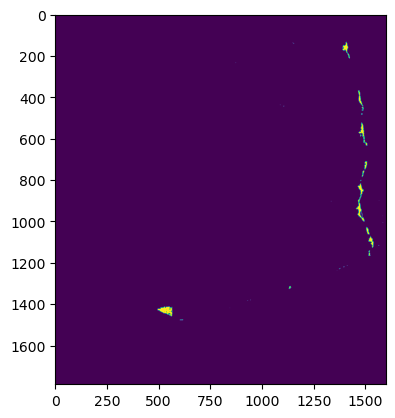

In [9]:
# Find areas, with high confidence minerals:
# Badellyite (zirconium)

## The standard thresholds: [15,   15,   15,   10 ,   20,   20,   30,  12,   5 ,   30,   10,   13 ,  92,   15,   5]
#                          ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
#plt.imshow(elems['Mg']>60), (elems['S']<20)*(elems['Ti']<20)*(elems['Cr']<15)*
#plt.imshow((elems['Si'] < 30)*(elems['Fe']>40)*(elems['Cr'] < 15)) 
plt.imshow(elems['Al']>50) 
m_masks = {}
m_masks['Feld-An-Al'] = np.logical_and(elems['Al']>20,elems['Na']>20)
m_masks['Feld-Al-Or'] = np.logical_and(elems['Al']>20,elems['K']>20)
m_masks['Pyr-cpx'] = elems['Ca']>20
m_masks['Pyr-opx'] = elems['Mg']>80
m_masks['Apatite'] = elems['P']>50
m_masks['Chromite'] = elems['Cr']>50
m_masks['Ilminite'] = elems['Ti']>25
m_masks['Pyrite'] = elems['S']>20
m_masks['Zircon'] = elems['Zr']>6
m_masks['Iron_oxide'] = ((elems['Si'] < 35)*(elems['Fe']>40)*(elems['Cr'] < 15)*(elems['Ti'] < 15)).astype(bool)
m_masks['Artifact'] = elems['Al']>50

In [43]:
pre_labelled_data = {}
data_flat = flatten_data(elems_nn)
box = 750,850,960,1040 # Feldspar An-Al
p_samples = {}
p_samples['Feld-An-Al'] = 0.3
p_samples['Feld-Al-Or'] =0.3
p_samples['Pyr-cpx'] = 0.1
p_samples['Pyr-opx'] = 0.1
p_samples['Apatite'] =0.0
p_samples['Chromite'] = 0.0
p_samples['Ilminite'] = 0.0
p_samples['Pyrite'] = 0.0
p_samples['Zircon'] = 0.0
p_samples['Iron_oxide'] = 0.0
p_samples['Artifact'] = 0.0
for key in m_masks.keys():
    pre_labelled_data[key] = augment_with_region(elems_nn, m_mask = m_masks[key], p_samples=p_samples[key])

data_flat_with_augm = np.vstack([data_flat] + list(pre_labelled_data.values()))

p_samples = {}
p_samples['Feld-An-Al'] = 0.0001
p_samples['Feld-Al-Or'] =0.0001
p_samples['Pyr-cpx'] = 0.0001
p_samples['Pyr-opx'] = 0.0001
p_samples['Apatite'] =0.00011
p_samples['Chromite'] = 0.0001
p_samples['Ilminite'] = 0.0001
p_samples['Pyrite'] = 0.0001
p_samples['Zircon'] = 0.0001
p_samples['Iron_oxide'] = 0.0001
p_samples['Artifact'] = 0.0001
for key in m_masks.keys():
    pre_labelled_data[key] = augment_with_region(elems_nn, m_mask = m_masks[key], p_samples=p_samples[key])
    

In [44]:
n_components = 15

from sklearn.decomposition import PCA
from sklearn.decomposition import SparsePCA
#pca = SparsePCA(n_components=n_components,alpha=10, max_iter=50)  # Keep all 15 components
pca = PCA(n_components=n_components)  # Keep all 15 components
pca.fit(data_flat_with_augm)  # Shape (1000000, 15)
orig_transform = pca.transform(data_flat)

aug_transform = {}
for key in pre_labelled_data.keys():
    aug_transform[key] = pca.transform(pre_labelled_data[key])


In [45]:
elements = ['Al', 'Ca', 'Cl', 'Cr', 'Fe',  'K', 'Mg', 'Na', 'Ni',  'O',  'P',  'S', 'Si', 'Ti', 'Zr']
import pandas as pd

# Get principal components (each row corresponds to a component, each column to a feature)
principal_components = pca.components_  # Shape (15, 15)

# Convert to a DataFrame for better readability
pc_df = pd.DataFrame(principal_components, 
                     index=[f"PC{i+1}" for i in range(principal_components.shape[0])], 
                     columns=[elements[i] for i in range(principal_components.shape[1])])

# Print the principal components
pc_df = pc_df.round(2)  # Round to 3 decimal places

# Adjust display settings to show more columns
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 200)  # Increase width to prevent truncation
print(pc_df)
print('Vars:', np.round(pca.explained_variance_ratio_,3))

        Al    Ca    Cl    Cr    Fe     K    Mg    Na    Ni     O     P     S    Si    Ti    Zr
PC1   0.14 -0.12 -0.05 -0.05 -0.10  0.96 -0.12  0.03 -0.02 -0.01 -0.08 -0.01  0.03 -0.03 -0.04
PC2  -0.14  0.34  0.40 -0.00 -0.00  0.16 -0.05 -0.12  0.00 -0.06  0.81  0.02 -0.06  0.01  0.04
PC3   0.65  0.15  0.04 -0.14 -0.31 -0.18 -0.35  0.46 -0.02  0.01  0.13 -0.04  0.03 -0.13 -0.18
PC4   0.15  0.08 -0.01  0.05  0.05  0.01 -0.17  0.10  0.03 -0.00 -0.05  0.05 -0.02  0.14  0.95
PC5   0.07  0.14  0.04  0.50  0.28  0.03 -0.32  0.09  0.13 -0.02 -0.08  0.27 -0.04  0.61 -0.25
PC6   0.10 -0.16  0.01  0.83 -0.07  0.01  0.08  0.02 -0.05  0.03  0.10 -0.18 -0.02 -0.46  0.06
PC7  -0.23  0.72 -0.10  0.05 -0.07  0.05 -0.17 -0.05  0.10 -0.07 -0.32  0.27  0.12 -0.41 -0.02
PC8   0.12 -0.35  0.07 -0.07  0.16 -0.03  0.03 -0.00  0.06  0.02  0.12  0.84 -0.08 -0.30  0.02
PC9  -0.62 -0.26  0.04 -0.02 -0.04  0.00 -0.32  0.62  0.13  0.08  0.07 -0.04  0.15 -0.08  0.02
PC10  0.16 -0.03  0.26 -0.15  0.65  0.01 -0.20 -0.

In [46]:
import matplotlib.patches as mpatches
N = 3
color_dict = {'Feld-An-Al': 'blue', 'Feld-Al-Or': 'purple', 'Pyr-cpx': 'pink', 'Pyr-opx': 'lime',
              'Apatite': 'orange', 'Chromite': 'cyan', 'Ilminite': 'yellow', 'Pyrite': 'red',
              'Zircon': 'magenta', 'Iron_oxide': 'brown', 'Artifact': 'black'}

# Create a 5x5 grid of plots
fig, axes = plt.subplots(N, N, figsize=(3*N, 3*N))

# Set figure background to light gray
fig.patch.set_facecolor("lightgray")

for k in range(1, N+1):  # Start from 1 to only show lower triangle of 6 PCs
    for j in range(k):  # j < k ensures only lower triangle
        ax = axes[k - 1, j]  # Shift index since grid is 5x5

        # Scatter original transformed data
        ax.scatter(orig_transform[:, k], orig_transform[:, j], color='grey', s=1, alpha=0.5)
        
        # Scatter each labeled dataset
        for key, data in aug_transform.items():
            ax.scatter(data[:, k], data[:, j], c=color_dict[key], label=key, alpha=0.7, s=2)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'PC{k} vs PC{j}', fontsize=14)

# Fill upper triangle and diagonal with gray
for k in range(N):
    for j in range(k+1, N):
        axes[k, j].set_facecolor('gray')
        axes[k, j].set_xticks([])
        axes[k, j].set_yticks([])

plt.tight_layout()
# Create a separate legend for the color labels
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in color_dict.items()]
fig.legend(handles=legend_patches, loc='upper right', title="Class Labels", fontsize=25, title_fontsize=40)

plt.savefig('/dtu-compute/msaca/cache/plot4.png',dpi=250)
plt.close('all')

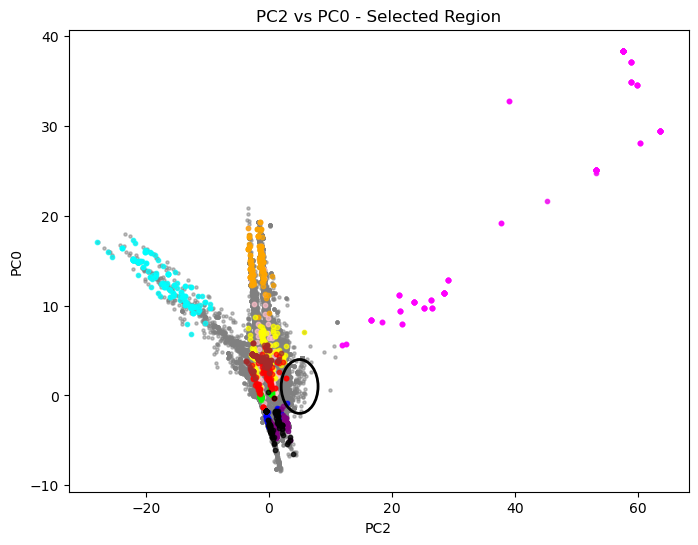

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Select principal components (k, j)
k, j = 2, 0  # Change these to your desired PCs

color_dict = {'Feld-An-Al': 'blue', 'Feld-Al-Or': 'purple', 'Pyr-cpx': 'pink', 'Pyr-opx': 'lime',
              'Apatite': 'orange', 'Chromite': 'cyan', 'Ilminite': 'yellow', 'Pyrite': 'red',
              'Zircon': 'magenta', 'Iron_oxide': 'brown', 'Artifact': 'black', 'Unsure': 'white'}

# Define circle center and radius
circle_center = (5, 1)  # (x, y) coordinates of the center
circle_radius = 3         # Radius of the selection

# Compute distance of all points from the center
distances = np.sqrt((orig_transform[:, k] - circle_center[0])**2 +
                    (orig_transform[:, j] - circle_center[1])**2)

# Select points inside the circle
selected_points = distances <= circle_radius

# Scatter original transformed data
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(orig_transform[:, k], orig_transform[:, j], color='grey', s=5, alpha=0.5)

# Scatter each labeled dataset
for key, data in aug_transform.items():
    ax.scatter(data[:, k], data[:, j], c=color_dict[key], label=key, alpha=0.7, s=10)

# Highlight selected points
#ax.scatter(orig_transform[selected_points, k], orig_transform[selected_points, j], color='black', s=5, alpha=1)

# Draw selection circle
circle = plt.Circle(circle_center, circle_radius, color='black', fill=False, linewidth=2)
ax.add_patch(circle)

# Labels
ax.set_title(f"PC{k} vs PC{j} - Selected Region")
ax.set_xlabel(f"PC{k}")
ax.set_ylabel(f"PC{j}")

plt.show()


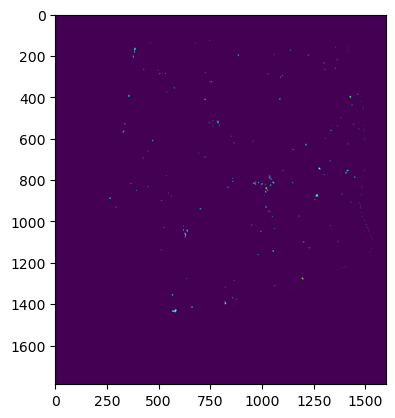

In [47]:
temp = np.zeros_like(mask)
temp[mask] = selected_points
plt.imshow(temp)

In [72]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from scipy.stats import mode
from scipy.spatial.distance import cosine, euclidean

# Define "Unsure" class label as a unique number
unsure_label =12  # Use -1 for unsure

# Prepare training data
X_train = np.vstack(list(aug_transform.values()))  # Stack labeled data
class_labels = ['Feld-An-Al', 'Feld-Al-Or', 'Pyr-cpx', 'Pyr-opx',
                'Apatite', 'Chromite', 'Ilminite', 'Pyrite',
                'Zircon', 'Iron_oxide', 'Artifact']

# Create a mapping from class names to numeric labels
class_to_number = {label: i+1 for i, label in enumerate(class_labels)}
y_train = np.concatenate([np.full(len(aug_transform[key]), class_to_number[key]) for key in aug_transform])


def combined_distance(x, y, alpha=0.1):
    # Calculate Euclidean distance
    euclidean_dist = euclidean(x, y)
    
    # Calculate Cosine distance
    cosine_dist = cosine(x, y)
    
    # Return weighted combination of both distances
    return alpha * euclidean_dist + (1 - alpha) * cosine_dist

# Define and fit the KNN classifier
k = 40  # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k, metric=combined_distance)
knn.fit(X_train, y_train)
X_test = orig_transform[::100]

# Predict the k-nearest neighbors for each test point
_, indices = knn.kneighbors(X_test)
neighbor_labels = y_train[indices]  # Shape (num_test_samples, k)

# Compute the most frequent label (majority vote)
majority_labels, counts = mode(neighbor_labels, axis=1, keepdims=True)
majority_labels = majority_labels.flatten()  # Convert to 1D array

# Count how many neighbors differ from the majority label
diff_counts = np.sum(neighbor_labels != majority_labels[:, None], axis=1)

# Assign labels: "Unsure" if 4 or more neighbors are different
y_pred_numeric = np.where(diff_counts >= 15, unsure_label, majority_labels)

# Print class distribution
from collections import Counter
print("Predicted Class Distribution:", Counter(y_pred_numeric))


KeyboardInterrupt: 

In [70]:
import matplotlib.patches as mpatches
N = 6
# Reverse the mapping: {1: 'Feld-An-Al', 2: 'Feld-Al-Or', ..., 11: 'Artifact'}
number_to_class = {v: k for k, v in class_to_number.items()}

# Convert numeric predictions to string labels
y_pred = np.array([number_to_class[num] if num in number_to_class else "Unsure" for num in y_pred_numeric])

# Create a 5x5 grid of plots
fig, axes = plt.subplots(N, N, figsize=(4*N, 4*N))

# Set figure background to light gray
fig.patch.set_facecolor("lightgray")

M = 100000
indices = np.random.choice(len(X_test), M, replace=True)  # Random sample without replacement
X_test_sampled = X_test[indices]
y_pred_sampled = y_pred[indices]
color_dict = {'Feld-An-Al': 'blue', 'Feld-Al-Or': 'purple', 'Pyr-cpx': 'pink', 'Pyr-opx': 'lime',
              'Apatite': 'orange', 'Chromite': 'cyan', 'Ilminite': 'yellow', 'Pyrite': 'red',
              'Zircon': 'magenta', 'Iron_oxide': 'brown', 'Artifact': 'black', 'Unsure': 'white'}
print(y_pred_sampled)
pred_colors_sampled = [color_dict[label] for label in y_pred_sampled]

for k in range(1, N+1):  # Start from 1 to only show lower triangle of 6 PCs
    for j in range(k):  # j < k ensures only lower triangle
        ax = axes[k - 1, j]  # Shift index since grid is 5x5

        # Scatter original transformed data
        ax.scatter(orig_transform[:, k], orig_transform[:, j], color='grey', s=1, alpha=0.5)
        
        # Scatter each labeled dataset
        for key, data in aug_transform.items():
            ax.scatter(data[:, k], data[:, j], c=color_dict[key], label=key, alpha=0.7, s=1, marker='x')

        ax.scatter(X_test_sampled[:, k], X_test_sampled[:, j], c=pred_colors_sampled, s=2, alpha=0.5)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f'PC{k} vs PC{j}', fontsize=14)

# Fill upper triangle and diagonal with gray
for k in range(N):
    for j in range(k+1, N):
        axes[k, j].set_facecolor('gray')
        axes[k, j].set_xticks([])
        axes[k, j].set_yticks([])

plt.tight_layout()
# Create a separate legend for the color labels
legend_patches = [mpatches.Patch(color=color, label=label) for label, color in color_dict.items()]
fig.legend(handles=legend_patches, loc='upper right', title="Class Labels", fontsize=25, title_fontsize=40)

plt.savefig('/dtu-compute/msaca/cache/plot3.png',dpi=250)
plt.close('all')

['Pyr-opx' 'Pyr-opx' 'Pyr-opx' ... 'Pyr-cpx' 'Feld-An-Al' 'Unsure']


In [71]:
segmentation_full = np.zeros_like(mask).astype(np.int8)
segmentation_full[mask] = y_pred_numeric


box = 0,1474,0,1595

y0, y1, x0, x1 = box
background = elems['Mg'][y0:y1,x0:x1]*1.0+0.0
ground_truth_seg = segmentation_full[y0:y1,x0:x1]
class_labels=['Background', 'Feld-An-Al', 'Feld-Al-Or', 'Pyr-cpx', 'Pyr-opx',
              'Apatite', 'Chromite', 'Ilminite', 'Pyrite',
              'Zircon', 'Iron_oxide', 'Artifact','Unsure']
plot_segmentations(background, ground_truth_seg, class_labels = class_labels,transparencies = [0, 0])